In [43]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [44]:
df = pd.read_csv("Titanic.csv", usecols=["Age","Fare","Survived"])

In [45]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [46]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [47]:
# Filling missing values with the median of that column
df['Age'] = df['Age'].fillna(df['Age'].median())
df["Fare"] = df["Age"].fillna(df["Fare"].median())

In [48]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [49]:
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=42)

/var/folders/2g/vcqv7bvn1xq6yxx44z_fdbr40000gn/T/ipykernel_1575/1182459444.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"])


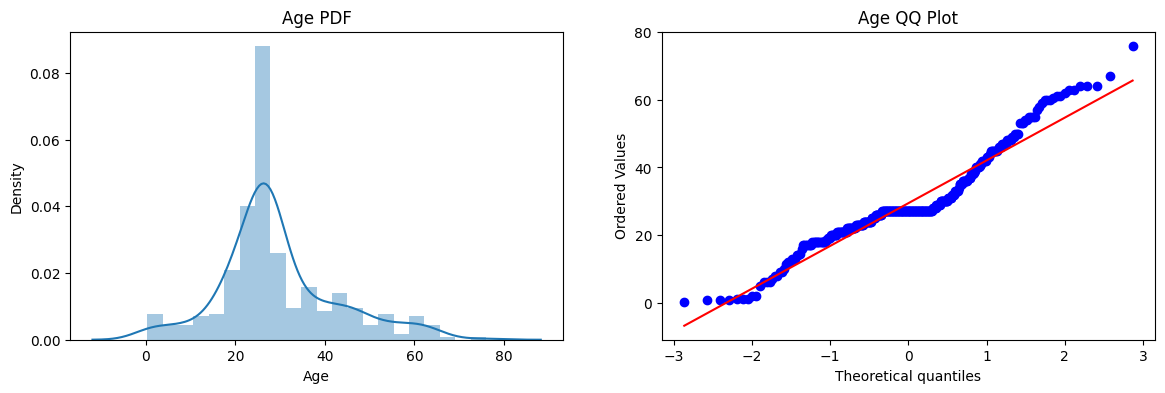

In [50]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train["Age"])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"], dist= "norm", plot= plt)
plt.title("Age QQ Plot")

plt.show()

/var/folders/2g/vcqv7bvn1xq6yxx44z_fdbr40000gn/T/ipykernel_1575/3612211313.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Fare"])


Text(0.5, 1.0, 'Fare QQ Plot')

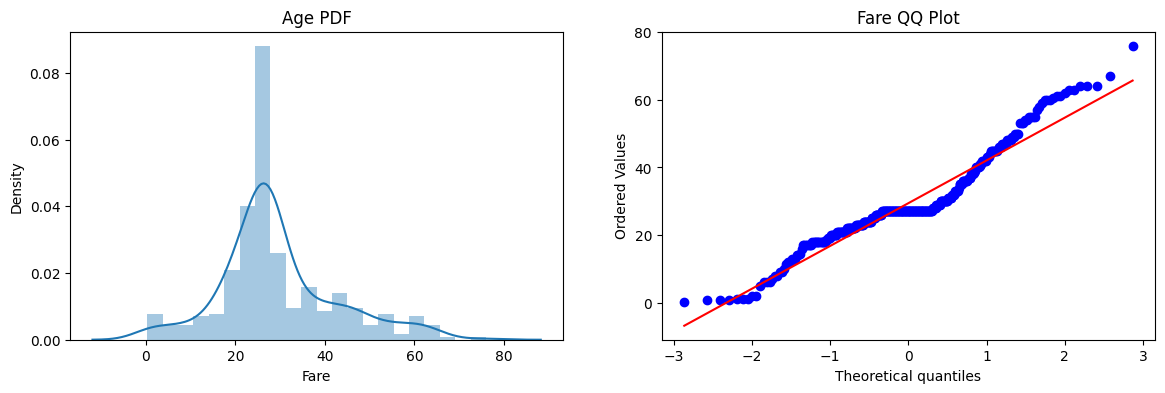

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train["Fare"])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"], dist = "norm", plot= plt)
plt.title("Fare QQ Plot")

In [52]:
clf = LogisticRegression()
clf1 = DecisionTreeClassifier()

In [72]:
clf.fit(X_train,y_train)
clf1.fit(X_train,y_train)

y_prad = clf.predict(X_test)
y_prad1 = clf1.predict(X_test)
print("Accuracy LR", accuracy_score(y_test,y_prad))
print("Accuracy QR", accuracy_score(y_test,y_prad1))

Accuracy LR 0.5952380952380952
Accuracy QR 0.5952380952380952
